In [1]:
import os
import matplotlib.pyplot as plt

def plot_freshness_from_labels(label_folder):
    x_vals = []
    y_vals = []

    txt_files = sorted(os.listdir(label_folder), key=lambda x: int(os.path.splitext(x)[0]))

    for file in txt_files:
        file_path = os.path.join(label_folder, file)
        with open(file_path, 'r') as f:
            lines = f.read().splitlines()
            if len(lines) >= 2:
                x = int(lines[0])
                y = float(lines[1])
                x_vals.append(x)
                y_vals.append(y)

    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals, linestyle='-', color='blue', label='Freshness Ratio')
    plt.title("Time vs Banana Freshness")
    plt.xlabel("Time (Image Index)")
    plt.ylabel("Freshness Ratio")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행



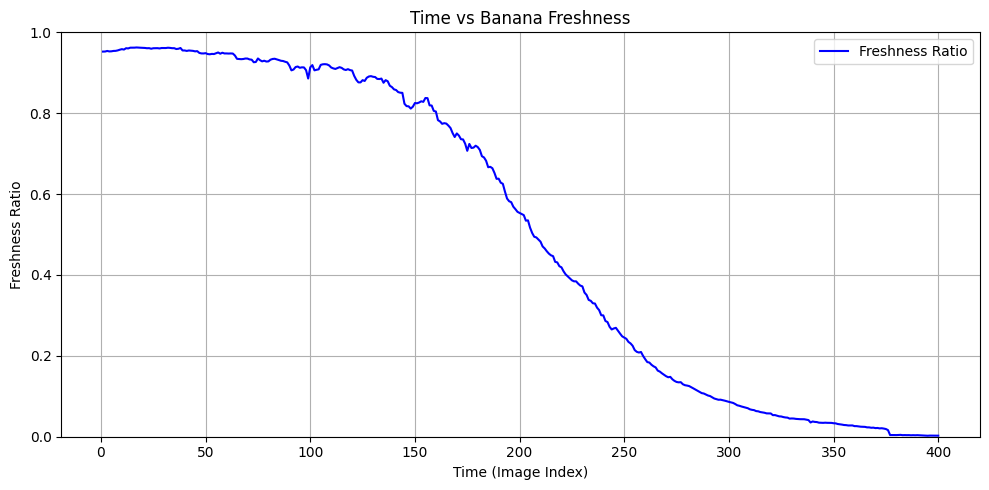

In [9]:
plot_freshness_from_labels("Dataset/banana_0/label")

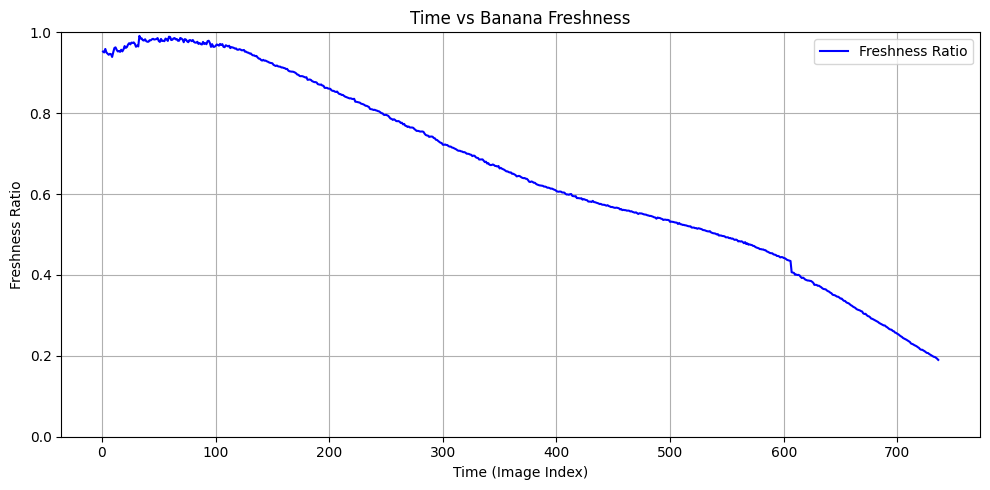

In [10]:
plot_freshness_from_labels("Dataset/banana_1/label")

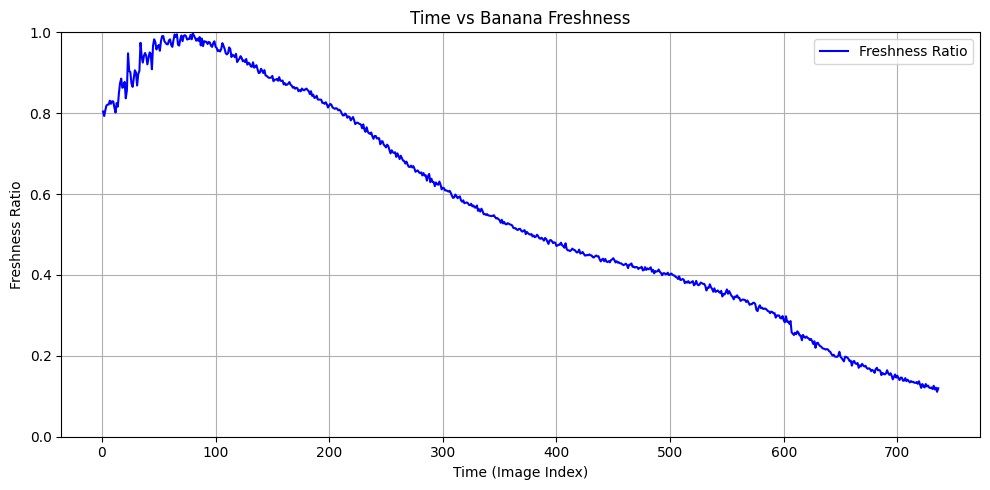

In [3]:
plot_freshness_from_labels("Dataset/banana_2/label")

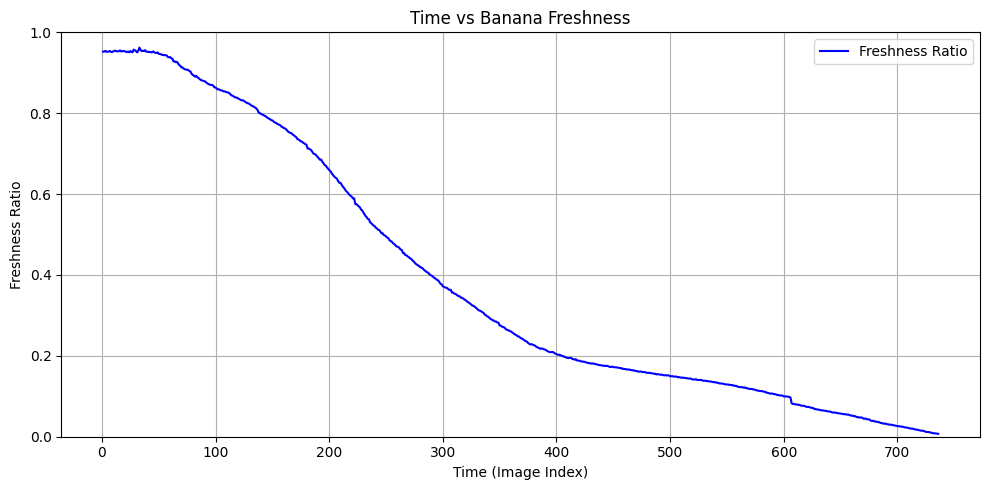

In [12]:
plot_freshness_from_labels("Dataset/banana_3/label")

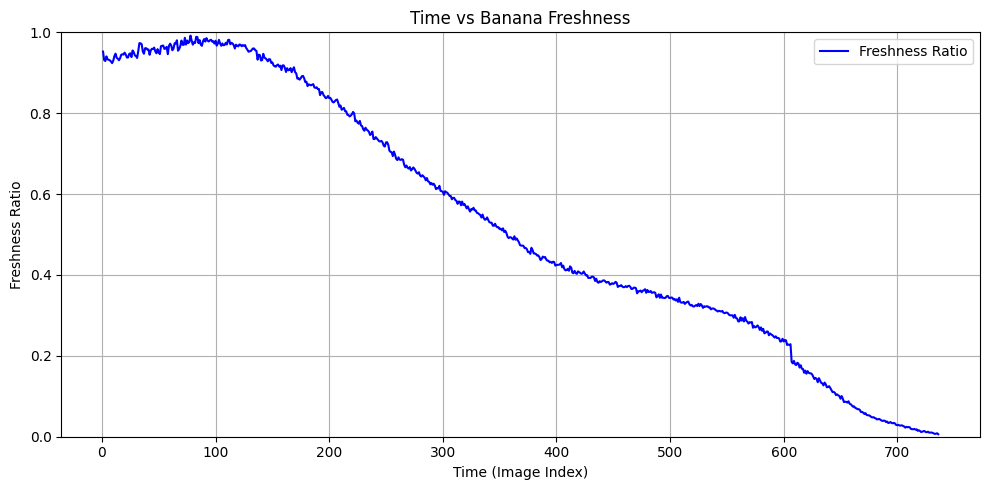

In [13]:
plot_freshness_from_labels("Dataset/banana_4/label")

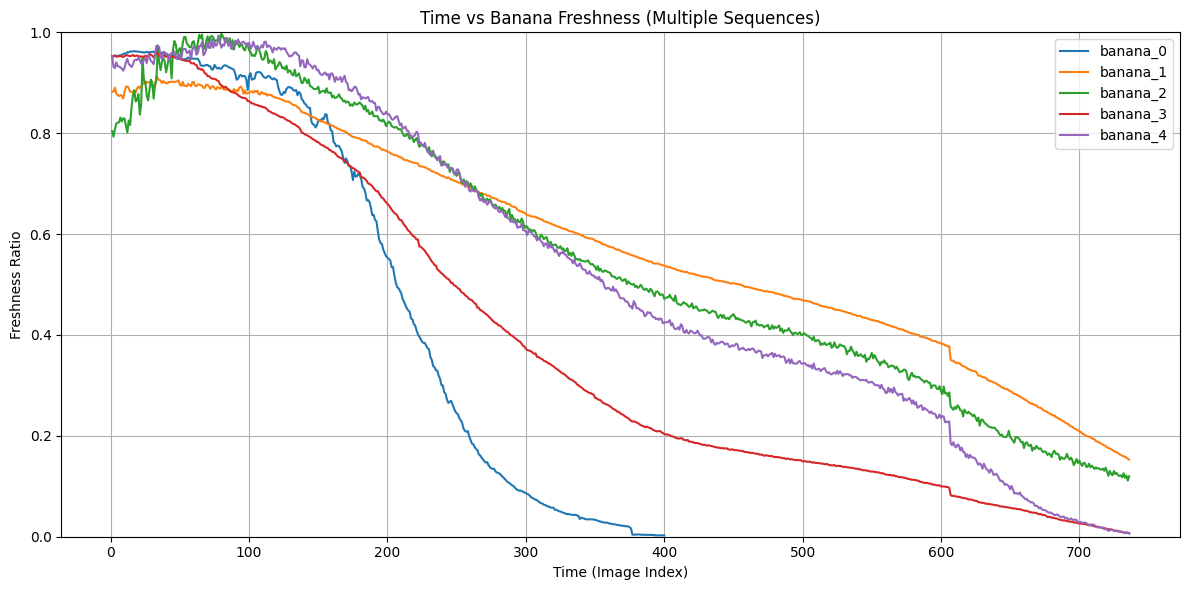

In [3]:
import os
import matplotlib.pyplot as plt

def plot_freshness_from_multiple_labels(base_folder, num_folders):
    plt.figure(figsize=(12, 6))

    for i in range(num_folders):
        label_folder = os.path.join(base_folder.replace('0', str(i)))
        x_vals = []
        y_vals = []

        txt_files = sorted(os.listdir(label_folder), key=lambda x: int(os.path.splitext(x)[0]))

        for file in txt_files:
            file_path = os.path.join(label_folder, file)
            with open(file_path, 'r') as f:
                lines = f.read().splitlines()
                if len(lines) >= 2:
                    x = int(lines[0])
                    y = float(lines[1])
                    x_vals.append(x)
                    y_vals.append(y)

        plt.plot(x_vals, y_vals, linestyle='-', label=f'banana_{i}')

    plt.title("Time vs Banana Freshness (Multiple Sequences)")
    plt.xlabel("Time (Image Index)")
    plt.ylabel("Freshness Ratio")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행
plot_freshness_from_multiple_labels("Dataset/banana_0/label", 5)


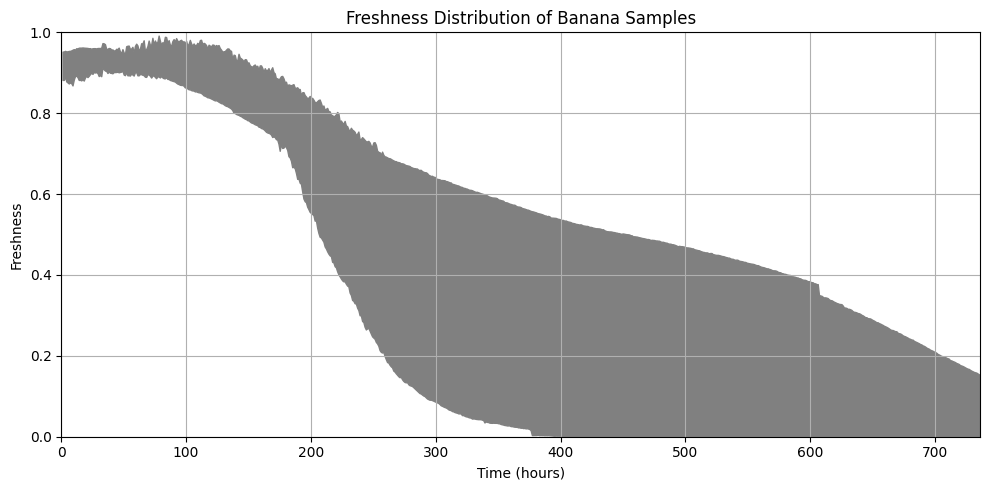

In [19]:
import os
import matplotlib.pyplot as plt

def read_labels(label_folder):
    x_vals = []
    y_vals = []

    txt_files = sorted(os.listdir(label_folder), key=lambda x: int(os.path.splitext(x)[0]))

    for file in txt_files:
        file_path = os.path.join(label_folder, file)
        with open(file_path, 'r') as f:
            lines = f.read().splitlines()
            if len(lines) >= 2:
                x = int(lines[0])
                y = float(lines[1])
                x_vals.append(x)
                y_vals.append(y)

    return x_vals, y_vals

# 라벨 폴더 리스트
label_folders = ['Dataset/banana_0/label','Dataset/banana_1/label','Dataset/banana_3/label','Dataset/banana_4/label']

# 모든 y 데이터를 저장할 리스트
all_y = []
x_common = None

# 각 폴더의 데이터를 읽음
for folder in label_folders:
    x_vals, y_vals = read_labels(folder)
    if x_common is None:
        x_common = x_vals
    else:
        # 공통된 x 길이로 맞추기
        min_len = min(len(x_common), len(x_vals))
        x_common = x_common[:min_len]
        y_vals = y_vals[:min_len]
    all_y.append(y_vals[:len(x_common)])

# 리스트를 전치하여 각 시간별 모든 바나나 y값 확보
y_transposed = list(zip(*all_y))

# 각 시간별 최소, 최대 y값 계산
y_min = [min(ys) for ys in y_transposed]
y_max = [max(ys) for ys in y_transposed]

# 그래프 그리기
plt.figure(figsize=(10, 5))

# 회색 범위만 표시
plt.fill_between(x_common, y_min, y_max, color='gray', alpha=1)

plt.title("Freshness Distribution of Banana Samples")
plt.xlabel("Time (hours)")
plt.ylabel("Freshness")
plt.xlim(0, 736)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


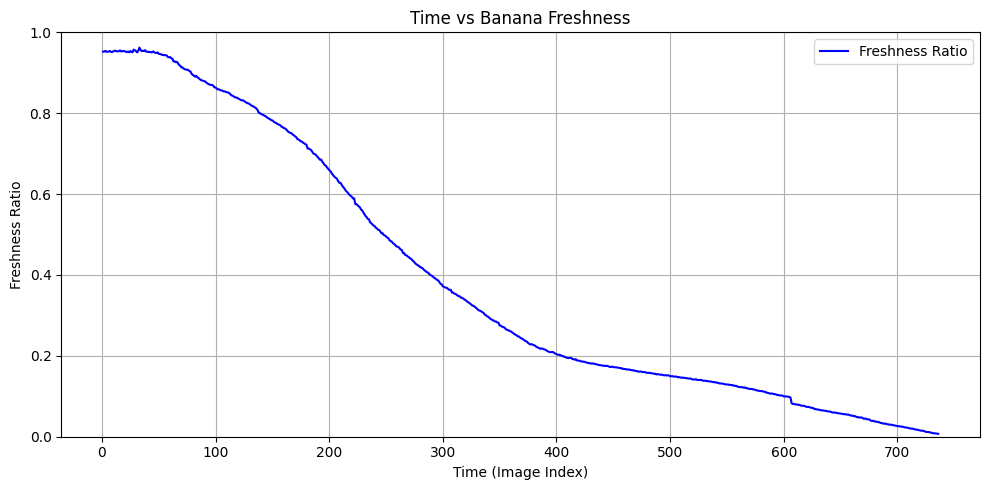

In [49]:
plot_freshness_from_labels("Dataset/banana_3/label")


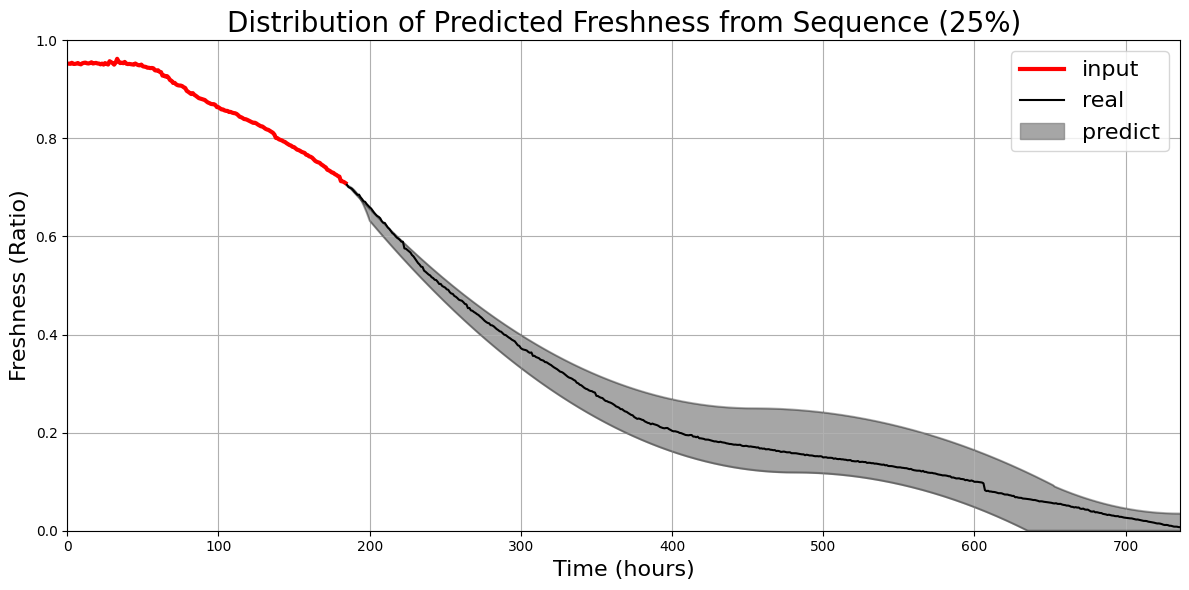

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

def read_labels(label_folder):
    x_vals = []
    y_vals = []

    txt_files = sorted(os.listdir(label_folder), key=lambda x: int(os.path.splitext(x)[0]))

    for file in txt_files:
        file_path = os.path.join(label_folder, file)
        with open(file_path, 'r') as f:
            lines = f.read().splitlines()
            if len(lines) >= 2:
                x = int(lines[0])
                y = float(lines[1])
                x_vals.append(x)
                y_vals.append(y)

    return x_vals, y_vals
""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# 실제 데이터 로딩
label_folder = 'Dataset/banana_3/label'
x_real, y_real = read_labels(label_folder)

# 시뮬레이션용 x 생성
x_sim = np.array(x_real)
y_sim = np.zeros_like(x_sim, dtype=np.float32)

# 0~49: 일정 유지 + 진동
y_sim[:184] = x_sim[:184]
file_path = r'D:\2025_Banana\Dataset\banana_3\label\184.txt'

with open(file_path, 'r') as f:
    lines = f.read().splitlines()
value = float(lines[1])
u = 200
v = 481
w = 736
# 50~220: 위로 볼록한 감소 (2차함수)
# 시작점 y=~0.96, 끝점 대략 y=0.6 근방
x1 = x_sim[184:u]
y1 = -0.00028 * (x1 - 184)**2 + value -0.005
y_sim[184:u] = y1

# 220~400: 아래로 볼록한 감소 (완만해지는 2차함수)
x2 = x_sim[u:v]
y2 = 0.0000065 * (x2 - v)**2 + y1[-1] - 0.0000065* ((v-u)**2) # 220 구간의 끝에서 부드럽게 이어짐
y_sim[u:v] = y2


x3 = x_sim[v:]
y3 = -0.000005 * (x3 - v)**2 + y2[-1]
y_sim[v:] = y3

# y 값 클리핑
y_sim = np.clip(y_sim, 0, 1)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 시뮬레이션용 x 생성
x_sim2 = np.array(x_real)
y_sim2 = np.zeros_like(x_sim, dtype=np.float32)

y_sim2[:184] = x_sim2[:184]
u = 184
v = 454
w = 652

# 220~400: 아래로 볼록한 감소 (완만해지는 2차함수)
x22 = x_sim2[u:v]
y22 = 0.0000063 * (x22 - v)**2 + value - 0.0000063* ((v-u)**2) # 220 구간의 끝에서 부드럽게 이어짐
y_sim2[u:v] = y22


x33 = x_sim2[v:w]
y33 = -0.000004 * (x33 - v)**2 + y22[-1]
y_sim2[v:w] = y33

x4 = x_sim2[w:]
y4 = 0.000008 * (x4 - 736)**2 + y33[-1] - 0.000008* ((737-w)**2)
y_sim2[w:] = y4

# y 값 클리핑
y_sim2 = np.clip(y_sim2, 0, 1)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# 그래프 출력
plt.figure(figsize=(12, 6))
plt.plot(x_real[:184], y_real[:184], label='input', color='r', linewidth=3)
plt.plot(x_real[184:], y_real[184:], label='real', color='k')
plt.plot(x_sim[184:], y_sim[184:], color='k', alpha = 0.3)
plt.plot(x_sim2[184:], y_sim2[184:], color='k', alpha = 0.3)
plt.fill_between(x_real[184:], y_sim[184:], y_sim2[184:], label='predict', color='gray', alpha=0.7)
plt.title("Distribution of Predicted Freshness from Sequence (25%)",fontsize=20)
plt.xlabel("Time (hours)", fontsize=16)
plt.ylabel("Freshness (Ratio)", fontsize=16)
plt.xlim(0, 736)
plt.ylim(0, 1)
plt.grid(True)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import mean_absolute_error

# 실제값과 예측값의 비교 범위: 184~
y_true = np.array(y_real[184:])
y_pred1 = np.array(y_sim[184:])
y_pred2 = np.array(y_sim2[184:])

# MAE 계산
mae1 = mean_absolute_error(y_true, y_pred1)
mae2 = mean_absolute_error(y_true, y_pred2)

# 평균 MAE
mean_mae = (mae1 + mae2) / 2

# 결과 출력
print(f"MAE for y_sim     : {mae1:.4f}")
print(f"MAE for y_sim2    : {mae2:.4f}")
print(f"Average MAE       : {mean_mae:.4f}")


MAE for y_sim     : 0.0386
MAE for y_sim2    : 0.0482
Average MAE       : 0.0434


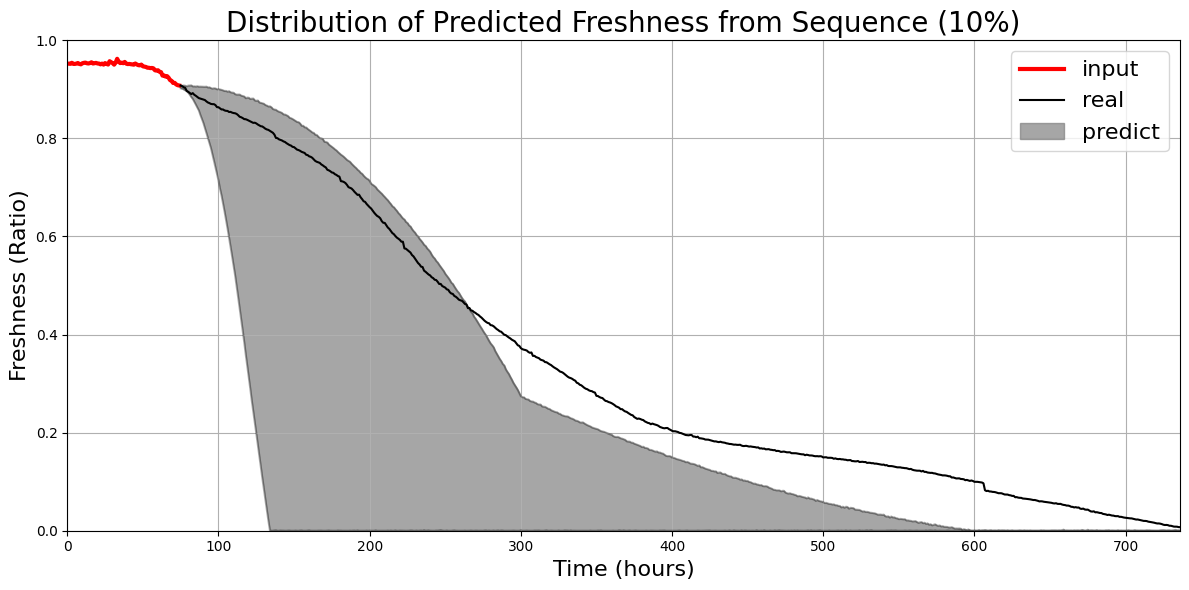

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

def add_noise(y, noise_level=0.01):
    noise = np.random.normal(loc=0.0, scale=noise_level, size=y.shape)
    y_noisy = y + noise
    return np.clip(y_noisy, 0, 1)  # 0~1 사이로 클리핑

def read_labels(label_folder):
    x_vals = []
    y_vals = []

    txt_files = sorted(os.listdir(label_folder), key=lambda x: int(os.path.splitext(x)[0]))

    for file in txt_files:
        file_path = os.path.join(label_folder, file)
        with open(file_path, 'r') as f:
            lines = f.read().splitlines()
            if len(lines) >= 2:
                x = int(lines[0])
                y = float(lines[1])
                x_vals.append(x)
                y_vals.append(y)

    return x_vals, y_vals
""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# 실제 데이터 로딩
label_folder = 'Dataset/banana_3/label'
x_real, y_real = read_labels(label_folder)

# 시뮬레이션용 x 생성
x_sim = np.array(x_real)
y_sim = np.zeros_like(x_sim, dtype=np.float32)

# 0~49: 일정 유지 + 진동
st = 74
y_sim[:st] = x_sim[:st]
file_path = r'D:\2025_Banana\Dataset\banana_3\label\074.txt'

with open(file_path, 'r') as f:
    lines = f.read().splitlines()
value = float(lines[1])
u = 115
v = 300
w = 736
# 50~220: 위로 볼록한 감소 (2차함수)
# 시작점 y=~0.96, 끝점 대략 y=0.6 근방
x1 = x_sim[st:u]
y1 = -0.00028 * (x1 - st)**2 + value -0.005
y_sim[st:u] = y1

# 220~400: 아래로 볼록한 감소 (완만해지는 2차함수)
x2 = x_sim[u:v]
m=0.000065
y2 =  m* (x2 - v)**2 + y1[-1] - m* ((v-u)**2) # 220 구간의 끝에서 부드럽게 이어짐
y_sim[u:v] = y2


x3 = x_sim[v:]
y3 = -0.000005 * (x3 - v)**2 + y2[-1]
y_sim[v:] = y3

# y 값 클리핑
y_sim = np.clip(y_sim, 0, 1)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 시뮬레이션용 x 생성
x_sim2 = np.array(x_real)
y_sim2 = np.zeros_like(x_sim, dtype=np.float32)

y_sim2[:st] = x_sim2[:st]
u = st
v = st+1
w = 300

# 220~400: 아래로 볼록한 감소 (완만해지는 2차함수)
x22 = x_sim2[u:v]
y22 = 0.0000063 * (x22 - v)**2 + value - 0.0000063* ((v-u)**2) # 220 구간의 끝에서 부드럽게 이어짐
y_sim2[u:v] = y22


x33 = x_sim2[v:w]
y33 = -0.0000125 * (x33 - v)**2 + y22[-1]
y_sim2[v:w] = y33

x4 = x_sim2[w:]
y4 = 0.0000016 * (x4 - 736)**2 + y33[-1] - 0.0000016* ((737-w)**2)
y_sim2[w:] = y4

# y 값 클리핑
y_sim2 = np.clip(y_sim2, 0, 1)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

y_sim_noisy = add_noise(y_sim, noise_level=0.0005)
y_sim2_noisy = add_noise(y_sim2, noise_level=0.0008)


""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# 그래프 출력
plt.figure(figsize=(12, 6))
plt.plot(x_real[:st], y_real[:st], label='input', color='r', linewidth=3)
plt.plot(x_real[st:], y_real[st:], label='real', color='k')
plt.plot(x_sim[st:], y_sim_noisy[st:], color='k', alpha = 0.3)
plt.plot(x_sim2[st:], y_sim2_noisy[st:], color='k', alpha = 0.3)
plt.fill_between(x_real[st:], y_sim_noisy[st:], y_sim2_noisy[st:], label='predict', color='gray', alpha=0.7)
plt.title("Distribution of Predicted Freshness from Sequence (10%)",fontsize=20)
plt.xlabel("Time (hours)", fontsize=16)
plt.ylabel("Freshness (Ratio)", fontsize=16)
plt.xlim(0, 736)
plt.ylim(0, 1)
plt.grid(True)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import mean_absolute_error

# 실제값과 예측값의 비교 범위: 184~
y_true = np.array(y_real[74:])
y_pred1 = np.array(y_sim_noisy[74:])
y_pred2 = np.array(y_sim2_noisy[74:])

# MAE 계산
mae1 = mean_absolute_error(y_true, y_pred1)
mae2 = mean_absolute_error(y_true, y_pred2)

# 평균 MAE
mean_mae = (mae1*4 + mae2) / 5

# 결과 출력
print(f"MAE for y_sim     : {mae1:.4f}")
print(f"MAE for y_sim2    : {mae2:.4f}")
print(f"Average MAE       : {mean_mae:.4f}")

MAE for y_sim     : 0.2733
MAE for y_sim2    : 0.0616
Average MAE       : 0.2310


In [ ]:
print(736*0.1)
file_path = r'D:\2025_Banana\Dataset\banana_3\label\184.txt'

with open(file_path, 'r') as f:
    lines = f.read().splitlines()
value = float(lines[1])

if len(lines) >= 2:
    value = float(lines[1])
    print("두 번째 줄의 float 값:", value)
else:
    print("파일에 두 번째 줄이 존재하지 않습니다.")


184.0
두 번째 줄의 float 값: 0.70894574


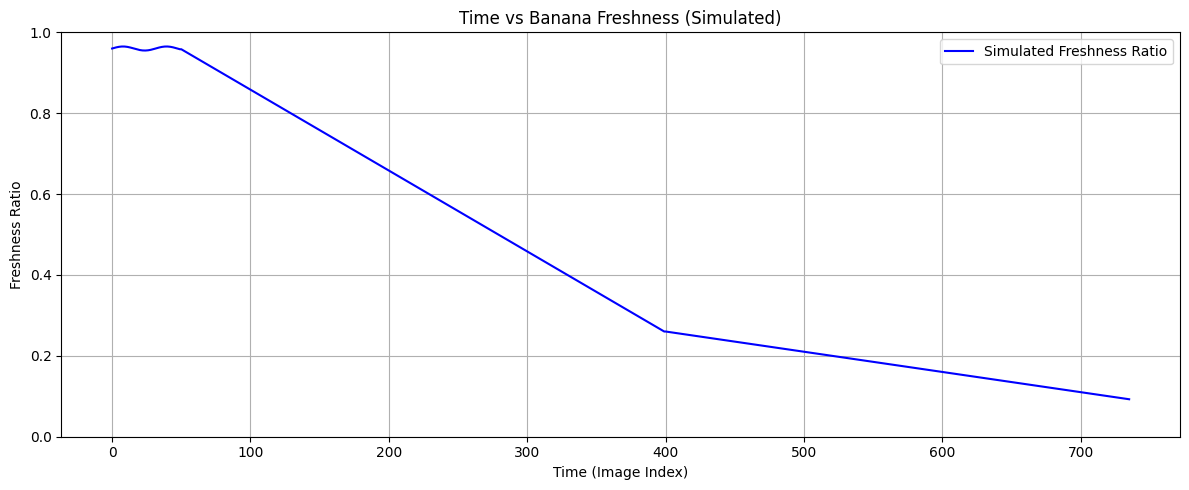

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# x값: 0 ~ 735
x = np.arange(0, 736)

# y값 초기화
y = np.zeros_like(x, dtype=np.float32)

# 0~49: 거의 일정 (살짝의 진동)
y[:50] = 0.96 + 0.005 * np.sin(0.2 * x[:50])

# 50~399: 선형 감소
y[50:400] = -0.002 * (x[50:400] - 50) + y[49]  # y[49]를 시작점으로 감소

# 400~735: 느린 감소 (비선형 형태 보정)
slope = -0.0005  # 더 완만한 기울기
y[400:] = slope * (x[400:] - 400) + y[399]

# y값 클리핑 (0~1 사이)
y = np.clip(y, 0, 1)

# 그래프 출력
plt.figure(figsize=(12, 5))
plt.plot(x, y, label='Simulated Freshness Ratio', color='blue')
plt.title("Time vs Banana Freshness (Simulated)")
plt.xlabel("Time (Image Index)")
plt.ylabel("Freshness Ratio")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
